# 06. Public holidays and festive seasons (Version 5)

How does each station change on public holidays and during the festive seasons? This notebook compares the entries on those days with a **normal day** at the same station, and saves one figure per station and festival for the map.

| Section | What it does |
|---|---|
| 0 | Settings: which festivals, how long each window is |
| 1 | Load the daily entries (the yearly files cached by `05timeline1.ipynb`) |
| 2 | Match line codes to the places on the map |
| 3 | Holiday calendars and festival windows |
| 4 | A normal day for every station (the baseline) |
| 5 | Holiday effect per station and festival |
| 6 | Checks: network, station types, top and bottom stations |
| 7 | Save the outputs |

**How the effect is measured.** For each festival window (for example the Hari Raya week), every day's entries are compared with that station's **usual entries on the same day of the week**, taken from the four weeks before the window and four weeks after it, leaving out other holidays. The effect is the percentage difference over the whole window, pooled over every year with data (2023 to 2026):

- **-40%** means the station is 40% quieter than a normal week at that time of year;
- **+10%** means it is busier than usual.

Comparing the same day of the week matters: a holiday on a Monday is set against normal Mondays, not against an average day.

Needs `data/processed/stations.geojson` (notebook 01) and `station_population.csv` (notebook 04); reuses the yearly ridership files that `05timeline1.ipynb` saved in `data/raw`.

## 0. Settings

In [1]:
from pathlib import Path
import re, json
from datetime import datetime
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import holidays

FIRST_YEAR = 2023                 # <- earliest year to load (the data starts in 2023)
REFRESH_CURRENT_YEAR = False      # <- True = download the current year's file again (05timeline1 already did)

# Festive windows. Name shown on the map: (holiday name in the calendar, days before, days after).
# The window runs from "days before" the holiday to "days after" it. Holiday names come from the
# `holidays` library in English; print the calendar in Section 3 to see them all.
FESTIVALS = {
    "Hari Raya Aidilfitri":   ("Eid al-Fitr", 1, 6),        # <- the Hari Raya week, when many people travel home
    "Chinese New Year":       ("Chinese New Year", 1, 6),   # <- the Chinese New Year week
    "Deepavali":              ("Diwali", 1, 1),             # <- the day before, the day and the day after
    "Hari Raya Haji":         ("Eid al-Adha", 0, 0),        # <- the day itself
    "Christmas and New Year": ("Christmas Day", 1, 7),      # <- 24 December to 1 January
    "National Day (Merdeka)": ("National Day", 0, 0),       # <- 31 August
}
OTHER_HOLIDAYS = "Other public holidays"   # <- every remaining public holiday as one group (None to leave out)

# Optional: school holidays, which are not in the holidays library. Add them by hand from the
# Ministry of Education calendar, e.g. [("School holidays", "2025-05-29", "2025-06-09"), ...]
SCHOOL_HOLIDAYS = []              # <- list of (name, first day, last day); leave empty to skip

BASELINE_WEEKS = 4                # <- weeks before and after each window used as the "normal" level
GAP_AFTER_DAYS = 7                # <- days skipped after a window before the "after" weeks start (travel back home)
MIN_BASELINE_DAYS = 3             # <- a weekday needs at least this many normal days for a baseline

PROCESSED = Path("data/processed")
RAW = Path("data/raw")
RAW.mkdir(parents=True, exist_ok=True)
OD_URL = "https://storage.data.gov.my/transportation/rail/rapidrail_{year}_daily.parquet"
this_year = datetime.now().year
YEARS = list(range(FIRST_YEAR, this_year + 1))
print("Years:", YEARS, "| festivals:", list(FESTIVALS) + ([OTHER_HOLIDAYS] if OTHER_HOLIDAYS else []))

Years: [2023, 2024, 2025, 2026] | festivals: ['Hari Raya Aidilfitri', 'Chinese New Year', 'Deepavali', 'Hari Raya Haji', 'Christmas and New Year', 'National Day (Merdeka)', 'Other public holidays']


## 1. Load the daily entries

The same station entry totals as in notebook 05 (rows from a station to `A0: All Stations`), kept **by day** this time.

In [2]:
def get_year(year):
    path = RAW / f"rapidrail_{year}_daily.parquet"
    if not path.exists() or (REFRESH_CURRENT_YEAR and year == this_year):
        url = OD_URL.format(year=year)
        print(f"Downloading {url}")
        r = requests.get(url, timeout=600)
        r.raise_for_status()
        path.write_bytes(r.content)
    else:
        print(f"Using cached {path}")
    df = pd.read_parquet(path)
    df = df[~df["origin"].str.startswith("A0:") & df["destination"].str.startswith("A0:")]
    df = df[["origin", "date", "ridership"]].rename(columns={"origin": "od_station"})
    df["date"] = pd.to_datetime(df["date"])
    return df

entries = pd.concat([get_year(y) for y in YEARS], ignore_index=True)
entries = entries.groupby(["od_station", "date"], as_index=False)["ridership"].sum()
DATA_END = entries["date"].max()
print(f"\n{len(entries):,} station-days from {entries['date'].min().date()} to {DATA_END.date()}")

Using cached data\raw\rapidrail_2023_daily.parquet
Using cached data\raw\rapidrail_2024_daily.parquet
Using cached data\raw\rapidrail_2025_daily.parquet
Using cached data\raw\rapidrail_2026_daily.parquet

219,456 station-days from 2023-01-01 to 2026-09-27


## 2. Match line codes to the places on the map

The same rules as notebook 05: by code first (e.g. `KG18`), then by cleaned name. Days before a line code's first day with data are dropped, so a station is never compared before it opened.

In [3]:
def clean(s):
    s = str(s).lower()
    s = re.sub(r"^[a-z]{1,3}\d{1,3}\s*[:\-]\s*", "", s)
    s = s.split(" - ")[0]
    s = re.sub(r"\b(lrt|mrt|monorail|stesen|station)\b", "", s)
    return re.sub(r"[^a-z0-9]", "", s)

def norm_code(s):
    m = re.match(r"^\s*([A-Za-z]{1,3})0*(\d{1,3})\b", str(s))
    return (m.group(1) + m.group(2)).upper() if m else None

stations = gpd.read_file(PROCESSED / "stations.geojson")
code_to_key = {c.strip(): k for k, codes in zip(stations["key"], stations["codes"]) for c in str(codes).split(",")}
codes = pd.DataFrame({"od_station": entries["od_station"].unique()})
codes["key"] = codes["od_station"].map(norm_code).map(code_to_key).fillna(
    codes["od_station"].map(clean).where(lambda s: s.isin(set(stations["key"]))))
print(f"Matched {codes['key'].notna().sum()} of {len(codes)} line codes")
entries = entries.merge(codes, on="od_station").dropna(subset=["key"])

first_day = entries[entries["ridership"] > 0].groupby("od_station")["date"].min()
entries = entries[entries["date"] >= entries["od_station"].map(first_day)]

# Each station's state, for the state holidays (e.g. Federal Territory Day in Kuala Lumpur and Putrajaya only)
STATE_OF = {"W.P. Kuala Lumpur": "KUL", "W.P. Putrajaya": "PJY"}
stations["state"] = stations["district"].map(STATE_OF).fillna("SGR")    # every other district is in Selangor
entries["state"] = entries["key"].map(stations.set_index("key")["state"])
print(stations["state"].value_counts().rename({"KUL": "Kuala Lumpur", "PJY": "Putrajaya", "SGR": "Selangor"}).to_string())

Matched 166 of 166 line codes
state
Selangor        78
Kuala Lumpur    75
Putrajaya        1


## 3. Holiday calendars and festival windows

Public holidays for Kuala Lumpur, Putrajaya and Selangor come from the `holidays` library. Each festival gets one window per year, built around its holiday as set in Section 0. A window is used only if the data covers all of it.

In [4]:
cal = {s: holidays.Malaysia(years=YEARS, subdiv=s, language="en_US") for s in ["KUL", "PJY", "SGR"]}
names = {}   # date -> set of holiday names (any state)
for s, h in cal.items():
    for d, n in h.items():
        names.setdefault(pd.Timestamp(d), set()).update(x.strip() for x in n.split(";"))
all_holidays = set(names)

windows = []   # one row per festival and year
for fest, (hname, before, after) in FESTIVALS.items():
    days = sorted(d for d, ns in names.items() if hname in ns)
    for d in days:
        windows.append({"festival": fest, "year": d.year, "anchor": d,
                        "start": d - pd.Timedelta(days=before), "end": d + pd.Timedelta(days=after), "states": "all"})
for name, a, b in SCHOOL_HOLIDAYS:
    windows.append({"festival": name, "year": pd.Timestamp(a).year, "anchor": pd.Timestamp(a),
                    "start": pd.Timestamp(a), "end": pd.Timestamp(b), "states": "all"})
windows = pd.DataFrame(windows)

in_festival = set()
for w in windows.itertuples():
    in_festival.update(pd.date_range(w.start, w.end))

if OTHER_HOLIDAYS:   # remaining single holidays, each applying to the states that have it
    other = []
    for d in sorted(all_holidays - in_festival):
        states = [s for s in cal if d.date() in cal[s]]
        other.append({"festival": OTHER_HOLIDAYS, "year": d.year, "anchor": d, "start": d, "end": d,
                      "states": ",".join(states), "name": "; ".join(sorted(names[d]))})
    windows = pd.concat([windows, pd.DataFrame(other)], ignore_index=True)

windows = windows[windows["end"] <= DATA_END].reset_index(drop=True)          # the data must cover the window
not_normal = all_holidays | in_festival                                          # never used as a "normal" day
not_normal |= {d + pd.Timedelta(days=1) for d in all_holidays}                   # nor the day after a holiday
print(f"{len(windows)} windows up to {DATA_END.date()}:")
print(windows.groupby("festival")["year"].apply(lambda y: ", ".join(map(str, sorted(y)))).to_string())

65 windows up to 2026-09-27:
festival
Chinese New Year                                     2023, 2024, 2025, 2026
Christmas and New Year                                     2023, 2024, 2025
Deepavali                                                  2023, 2024, 2025
Hari Raya Aidilfitri                                 2023, 2024, 2025, 2026
Hari Raya Haji                                       2023, 2024, 2025, 2026
National Day (Merdeka)                               2023, 2024, 2025, 2026
Other public holidays     2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023...


## 4. A normal day for every station

For each window, the baseline for a station is its **median** entries on the same day of the week over the `BASELINE_WEEKS` weeks before the window and the same number of weeks after it (skipping `GAP_AFTER_DAYS` first, while people travel back). Holidays, festival windows and the day after a holiday are left out. The median resists one-off events such as a concert or a service disruption.

In [5]:
daily = entries.pivot_table(index="date", columns="od_station", values="ridership", aggfunc="sum")
code_key = entries.drop_duplicates("od_station").set_index("od_station")[["key", "state"]]

def window_effect(w):
    """Actual and expected entries per line code over one window."""
    win = pd.date_range(w.start, w.end)
    span = pd.Timedelta(weeks=BASELINE_WEEKS)
    before = pd.date_range(w.start - span, w.start - pd.Timedelta(days=1))
    after_start = w.end + pd.Timedelta(days=1 + GAP_AFTER_DAYS)
    after = pd.date_range(after_start, after_start + span - pd.Timedelta(days=1))
    base_days = [d for d in before.append(after) if d not in not_normal and d in daily.index]
    base = daily.loc[base_days]
    med = base.groupby(base.index.dayofweek).median()
    enough = base.notna().groupby(base.index.dayofweek).sum() >= MIN_BASELINE_DAYS
    med = med.where(enough)
    actual = daily.reindex(win)
    expected = med.reindex([d.dayofweek for d in win]).set_axis(win)   # the usual level for each window day
    ok = actual.notna().all() & expected.notna().all()            # every window day needs data and a baseline
    if w.states != "all":
        ok &= code_key.reindex(actual.columns)["state"].isin(w.states.split(",")).values
    out = pd.DataFrame({"actual": actual.sum(), "expected": expected.sum()})[ok.values]
    out["festival"], out["year"], out["start"], out["end"] = w.festival, w.year, w.start, w.end
    return out

parts = [window_effect(w) for w in windows.itertuples()]
by_code = pd.concat(parts).rename_axis("od_station").reset_index().join(code_key, on="od_station")
print(f"{len(by_code):,} line-code windows measured")

8,812 line-code windows measured


## 5. Holiday effect per station and festival

A place's effect adds up the actual and expected entries of all its line codes over every year with data, then compares the totals. So a big festival year counts for more than a small one-day holiday, and an interchange counts all its platforms.

In [6]:
g = by_code.groupby(["key", "festival"]).agg(actual=("actual", "sum"), expected=("expected", "sum"),
                                              years=("year", "nunique")).reset_index()
g["effect_pct"] = ((g["actual"] / g["expected"] - 1) * 100).round(1)
order = list(FESTIVALS) + [n for n, _, _ in SCHOOL_HOLIDAYS] + ([OTHER_HOLIDAYS] if OTHER_HOLIDAYS else [])
table = g.pivot(index="key", columns="festival", values="effect_pct").reindex(columns=[f for f in order if f in set(g["festival"])])
table = stations.set_index("key")[["name"]].join(table)
print("Median station effect (%):")
print(table.drop(columns="name").median().round(1).to_string())

Median station effect (%):
Hari Raya Aidilfitri     -28.2
Chinese New Year         -25.2
Deepavali                -17.3
Hari Raya Haji           -39.4
Christmas and New Year   -14.2
National Day (Merdeka)   -19.8
Other public holidays    -35.9


## 6. Checks

**Network:** the whole network's effect for each window, to see whether years agree. A one-day holiday that falls on a weekend changes little (it is set against normal weekends), while one on a working day loses its commuters, so single days vary more between years than the festive weeks. **Station types:** Version 3 split stations into four types; home-end stations should empty most when people travel home, and leisure destinations should hold up best. **Extremes:** the stations that change most and least.

In [7]:
net = by_code.groupby(["festival", "year", "start", "end"])[["actual", "expected"]].sum().reset_index()
net["network_effect_pct"] = ((net["actual"] / net["expected"] - 1) * 100).round(1)
net_named = net[net["festival"] != OTHER_HOLIDAYS]
print("Network effect by window:")
display(net_named.pivot(index="festival", columns="year", values="network_effect_pct").reindex(
    [f for f in order if f != OTHER_HOLIDAYS and f in set(net_named["festival"])]))

types = pd.read_csv(PROCESSED / "station_population.csv")[["key", "station_type", "entries_per_resident"]]
t = table.join(types.set_index("key")).join(stations.set_index("key")["weekend_ratio"])
print("Median effect by station type (%):")
display(t.groupby("station_type")[[c for c in table.columns if c != "name"]].median().round(1))

fest_cols = [c for c in table.columns if c != "name"]
print("Rank correlation of each holiday effect with the weekend ratio and with entries per resident:")
display(pd.DataFrame({"weekend ratio": t[fest_cols].rank().corrwith(t["weekend_ratio"].rank()).round(2),
                      "entries per resident": t[fest_cols].rank().corrwith(t["entries_per_resident"].rank()).round(2)}))

for fest in [c for c in table.columns if c != "name"][:2]:
    s = table[["name", fest]].dropna().sort_values(fest)
    print(f"\n{fest}: quietest stations")
    print(s.head(6).to_string(index=False))
    print(f"{fest}: stations that hold up best")
    print(s.tail(6).to_string(index=False))

Network effect by window:


year,2023,2024,2025,2026
festival,,,,
Hari Raya Aidilfitri,-21.9,-18.8,-23.1,-21.0
Chinese New Year,-22.6,-10.4,-16.3,-29.2
Deepavali,-3.9,-13.3,-11.9,NaN
Hari Raya Haji,-35.8,-35.9,-7.4,-39.2
Christmas and New Year,-4.4,-7.9,-7.0,NaN
National Day (Merdeka),-18.8,11.0,22.9,-29.3


Median effect by station type (%):


,Hari Raya Aidilfitri,Chinese New Year,Deepavali,Hari Raya Haji,Christmas and New Year,National Day (Merdeka),Other public holidays
station_type,,,,,,,
Home-end commuter,-29.1,-31.7,-22.3,-43.0,-21.0,-26.6,-41.8
Leisure destination,-13.6,-11.8,-4.1,-20.0,-2.9,-4.4,-23.9
Local neighbourhood,-20.8,-20.6,-12.6,-29.5,-10.0,-17.7,-30.4
Work-end commuter,-36.6,-32.8,-26.9,-53.6,-20.8,-32.4,-48.0


Rank correlation of each holiday effect with the weekend ratio and with entries per resident:


,weekend ratio,entries per resident
Hari Raya Aidilfitri,0.68,-0.06
Chinese New Year,0.75,0.07
Deepavali,0.84,0.08
Hari Raya Haji,0.82,-0.05
Christmas and New Year,0.85,0.07
National Day (Merdeka),0.73,0.15
Other public holidays,0.88,0.05



Hari Raya Aidilfitri: quietest stations
          name  Hari Raya Aidilfitri
       Merdeka                 -55.5
 Sultan Ismail                 -49.5
 Cgc Glenmarie                 -48.8
           UPM                 -47.3
Tun Sambanthan                 -47.2
      Kerinchi                 -45.6
Hari Raya Aidilfitri: stations that hold up best
                name  Hari Raya Aidilfitri
                KLCC                   4.7
Bandar Tasik Selatan                   5.5
       Bukit Bintang                   7.6
                Imbi                  14.1
          Pasar Seni                  15.3
            Chow Kit                  34.8

Chinese New Year: quietest stations
            name  Chinese New Year
         Merdeka             -49.5
  Tun Sambanthan             -47.6
      Jalan Ipoh             -46.9
     Wangsa Maju             -45.6
    Sri Petaling             -44.8
Phileo Damansara             -44.1
Chinese New Year: stations that hold up best
                name  C

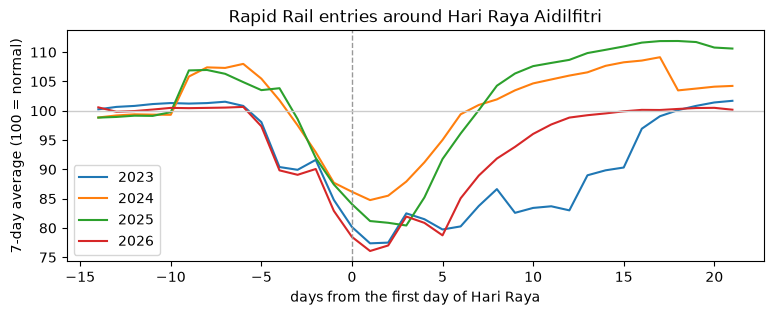

In [8]:
# Optional chart: the whole network, day by day, around each Hari Raya (needs matplotlib)
try:
    import matplotlib.pyplot as plt
    network_daily = daily.sum(axis=1, min_count=1)
    fig, ax = plt.subplots(figsize=(9, 3))
    hname = FESTIVALS["Hari Raya Aidilfitri"][0]
    for d in sorted(x for x, ns in names.items() if hname in ns and x <= DATA_END):
        s = network_daily[d - pd.Timedelta(days=24): d + pd.Timedelta(days=24)].rolling(7, center=True).mean()
        s = 100 * s / s[d - pd.Timedelta(days=17): d - pd.Timedelta(days=11)].mean()   # 100 = about two weeks before
        s = s[d - pd.Timedelta(days=14): d + pd.Timedelta(days=21)]
        ax.plot((s.index - d).days, s.values, label=str(d.year))
    ax.axvline(0, color="#999", lw=1, ls="--"); ax.axhline(100, color="#ccc", lw=1)
    ax.set_xlabel("days from the first day of Hari Raya"); ax.set_ylabel("7-day average (100 = normal)")
    ax.set_title("Rapid Rail entries around Hari Raya Aidilfitri"); ax.legend(); plt.show()
except ImportError:
    print("(Install matplotlib to see the chart.)")

## 7. Save the outputs

In [9]:
out = g[["key", "festival", "effect_pct", "years"]]
out.to_csv(PROCESSED / "station_holidays.csv", index=False)
net_out = net.copy()
for c in ["start", "end"]:
    net_out[c] = net_out[c].dt.strftime("%Y-%m-%d")
net_out[["festival", "year", "start", "end", "network_effect_pct"]].to_csv(PROCESSED / "holiday_windows.csv", index=False)

pooled = net.groupby("festival")[["actual", "expected"]].sum()
meta = {"festivals": [f for f in order if f in set(g["festival"])],
        "windows": {f: [before, after] for f, (_, before, after) in FESTIVALS.items()},
        "network_effect_pct": {f: round(float((pooled.loc[f, "actual"] / pooled.loc[f, "expected"] - 1) * 100), 1)
                               for f in pooled.index},
        "baseline_weeks": BASELINE_WEEKS, "gap_after_days": GAP_AFTER_DAYS, "data_end": str(DATA_END.date()),
        "prepared_on": datetime.now().strftime("%Y-%m-%d"),
        "notes": ["Effect = entries during the window compared with the same station's usual entries on the same day of the week, "
                  f"from {BASELINE_WEEKS} weeks before and after the window, pooled over every year with data."]}
(PROCESSED / "holiday_metadata.json").write_text(json.dumps(meta, indent=2))

for f in ["station_holidays.csv", "holiday_windows.csv", "holiday_metadata.json"]:
    print(f"{f:24} {(PROCESSED / f).stat().st_size / 1e3:8.1f} KB")

station_holidays.csv         38.6 KB
holiday_windows.csv           3.5 KB
holiday_metadata.json         1.2 KB


___
**END**